In [1]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from run_config import REPO_PATH, SEASONS, PROCESSED_DATA_PATH, FEATURES_PATH
from experiment_config import TARGET_RANGES, TEST_SIZE, VALIDATION_SIZE, RANDOM_STATE, EXPERIMENT_NAME, KEY_COLUMNS

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import align_on_keys
from src.model.model_utils import SklearnWrapper

In [2]:
features_path = f"{FEATURES_PATH}/all_combined_features.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [3]:
seasons=sorted(SEASONS)
target_dfs=[pd.read_csv(f"{PROCESSED_DATA_PATH}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=KEY_COLUMNS).columns.tolist()

In [4]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, KEY_COLUMNS)

In [5]:
def run_multiclass_distribution_experiment(
    feature_df,
    target_df,
    target_ranges,
    model_wrapper_class,
    model_param_grid,
    test_size,
    experiment_name,
    uri,
    model_name,
    valid_size,
    k,
    key_columns
):
    mlflow.set_tracking_uri(uri)
    mlflow.set_experiment(experiment_name)

    # Sort by date for time series split
    if not feature_df["date"].is_monotonic_increasing:
        raise ValueError("feature_df['date'] must be sorted in increasing order.")
    if not target_df["date"].is_monotonic_increasing:
        raise ValueError("target_df['date'] must be sorted in increasing order.")
    
    feature_df = feature_df.drop(columns=key_columns, errors='ignore')
    target_df = target_df.drop(columns=key_columns, errors='ignore')

    n_samples = len(feature_df)
    test_split = int(n_samples * (1 - test_size))
    train_valid_df = feature_df.iloc[:test_split]
    test_df = feature_df.iloc[test_split:]
    train_valid_target = target_df.iloc[:test_split]
    test_target = target_df.iloc[test_split:]

    # Calculate minimum training size (50% of train_valid data)
    n_train_valid = len(train_valid_df)
    min_train_size = n_train_valid // 2
    
    # Calculate the size of each split to ensure min_train_size
    # test_size parameter in TimeSeriesSplit represents the size of each validation fold
    fold_size = (n_train_valid - min_train_size) // k
    
    tscv = TimeSeriesSplit(n_splits=k, test_size=fold_size)

    # Store metrics for each parameter combination
    param_metrics = {}

    for fold, (train_idx, valid_idx) in enumerate(tscv.split(train_valid_df)):
        # No need to further split train_idx as TimeSeriesSplit now handles the minimum size
        X_train = train_valid_df.iloc[train_idx]
        y_train_df = train_valid_target.iloc[train_idx]
        X_valid = train_valid_df.iloc[valid_idx]
        y_valid_df = train_valid_target.iloc[valid_idx]
        X_test = test_df
        y_test_df = test_target

        print(f"\nFold {fold+1} training size: {len(train_idx)} ({len(train_idx)/n_train_valid:.1%} of data)")

        for target_col, (lower_bound, upper_bound) in target_ranges.items():
            print(f"\n--- Fold {fold+1} | Training for target: {target_col} ---")
            y_train = y_train_df[target_col]
            y_valid = y_valid_df[target_col]
            y_test = y_test_df[target_col]

            all_classes = sorted(y_train.unique())
            class_to_idx = {c: i for i, c in enumerate(all_classes)}
            idx_to_class = {i: c for c, i in class_to_idx.items()}

            y_train_encoded = y_train.map(class_to_idx)
            y_valid_encoded = y_valid.map(class_to_idx)
            y_test_encoded = y_test.map(class_to_idx)

            keys, values = zip(*model_param_grid.items()) if model_param_grid else ([], [])
            for param_combination in product(*values) if values else [()]:
                model_params = dict(zip(keys, param_combination))
                param_key = tuple(model_params.items())
                
                if param_key not in param_metrics:
                    param_metrics[param_key] = {
                        'target_col': target_col,
                        'params': model_params,
                        'metrics': defaultdict(list)
                    }

                model = model_wrapper_class(**model_params)
                model.fit(X_train, y_train_encoded)

                for split_name, X_split, y_split, y_split_encoded in [
                    ("train", X_train, y_train, y_train_encoded),
                    ("valid", X_valid, y_valid, y_valid_encoded),
                    ("test", X_test, y_test, y_test_encoded)
                ]:
                    proba = model.predict_proba(X_split)
                    predicted_class_indices = np.argmax(proba, axis=1)
                    predicted_classes = np.array([idx_to_class[i] for i in predicted_class_indices])

                    # Base accuracy
                    base_acc = accuracy_score(y_split, predicted_classes)
                    param_metrics[param_key]['metrics'][f"{target_col}_{split_name}_top1_accuracy"].append(base_acc)

                    # Calculate metrics for greater than thresholds
                    for threshold in range(lower_bound, upper_bound + 1):
                        y_true_binary = (y_split > threshold).astype(int)
                        proba_gt = np.zeros(len(y_split))
                        for cls, idx in class_to_idx.items():
                            if cls > threshold:
                                proba_gt += proba[:, idx]
                        y_pred_binary = (proba_gt >= 0.5).astype(int)
                        acc = accuracy_score(y_true_binary, y_pred_binary)
                        prec = precision_score(y_true_binary, y_pred_binary, zero_division=0)
                        
                        param_metrics[param_key]['metrics'][f"{target_col}_{split_name}_gt_{threshold}_accuracy"].append(acc)
                        param_metrics[param_key]['metrics'][f"{target_col}_{split_name}_gt_{threshold}_precision"].append(prec)

                    # Calculate metrics for less than or equal threshold
                    y_true_le = (y_split <= lower_bound).astype(int)
                    proba_gt_lb = np.zeros(len(y_split))
                    for cls, idx in class_to_idx.items():
                        if cls > lower_bound:
                            proba_gt_lb += proba[:, idx]
                    proba_le = 1 - proba_gt_lb
                    y_pred_le = (proba_le >= 0.5).astype(int)
                    acc_le = accuracy_score(y_true_le, y_pred_le)
                    prec_le = precision_score(y_true_le, y_pred_le, zero_division=0)
                    
                    param_metrics[param_key]['metrics'][f"{target_col}_{split_name}_lte_{lower_bound}_accuracy"].append(acc_le)
                    param_metrics[param_key]['metrics'][f"{target_col}_{split_name}_lte_{lower_bound}_precision"].append(prec_le)

                #print(f"Computed metrics for {target_col} fold {fold+1} with params: {model_params}")

    # Log average metrics across folds for each parameter combination
    for param_key, param_data in param_metrics.items():
        run_name = f"{model_name}_{param_data['target_col']}_" + "_".join(f"{k}={v}" for k, v in param_data['params'].items())
        
        with mlflow.start_run(run_name=run_name):
            mlflow.log_param("target", param_data['target_col'])
            mlflow.log_param("model_name", model_name)
            mlflow.log_params(param_data['params'])

            # Log average metrics across folds
            for metric_name, values in param_data['metrics'].items():
                avg_value = np.mean(values)
                std_value = np.std(values)
                mlflow.log_metric(f"{metric_name}", avg_value)
                mlflow.log_metric(f"{metric_name}_std", std_value)

            print(f"Logged cross-validation metrics for {param_data['target_col']} with params: {param_data['params']}")

In [6]:
param_grid = {
    'hidden_layer_sizes': [(64, 32, 32), (32, 16), (128, 32, 16)],
    'activation': ['relu'],
    'solver': ['adam'],
    'alpha': [0.001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.005],
    'batch_size': [32, 64],
    'max_iter': [1000],
}


In [7]:
feature_df.fillna(-1, inplace=True)

In [8]:
run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TARGET_RANGES,
    model_wrapper_class=lambda **params: SklearnWrapper(MLPClassifier, **params),
    model_param_grid=param_grid,
    test_size=TEST_SIZE,
    valid_size=VALIDATION_SIZE,
    k=5,
    experiment_name=EXPERIMENT_NAME,
    uri=f'{REPO_PATH}/mlflow',
    model_name='MLPClassifier',
    key_columns=KEY_COLUMNS
)



Fold 1 training size: 679 (50.0% of data)

--- Fold 1 | Training for target: home_goals ---

--- Fold 1 | Training for target: away_goals ---

Fold 2 training size: 815 (60.0% of data)

--- Fold 2 | Training for target: home_goals ---

--- Fold 2 | Training for target: away_goals ---

Fold 3 training size: 951 (70.0% of data)

--- Fold 3 | Training for target: home_goals ---

--- Fold 3 | Training for target: away_goals ---

Fold 4 training size: 1087 (80.0% of data)

--- Fold 4 | Training for target: home_goals ---

--- Fold 4 | Training for target: away_goals ---

Fold 5 training size: 1223 (90.0% of data)

--- Fold 5 | Training for target: home_goals ---

--- Fold 5 | Training for target: away_goals ---
Logged cross-validation metrics for home_goals with params: {'hidden_layer_sizes': (64, 32, 32), 'activation': 'relu', 'solver': 'adam', 'alpha': 0.001, 'learning_rate_init': 0.001, 'batch_size': 32, 'max_iter': 1000}
Logged cross-validation metrics for home_goals with params: {'hid

In [9]:
def plot_metrics_for_target_and_model(
    experiment_name, target_col, model_name, tracking_uri, top_n=5
):
    mlflow.set_tracking_uri(tracking_uri)
    experiment = mlflow.get_experiment_by_name(experiment_name)

    # Search runs
    filter_string = f"params.target = '{target_col}' and params.model_name = '{model_name}'"
    runs = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=filter_string,
        output_format="pandas"
    )

    if runs.empty:
        print("No matching runs found.")
        return

    # Extract test metrics without standard deviations
    metric_rows = []
    for _, run in runs.iterrows():
        run_id = run["run_id"]
        run_name = run.get("tags.mlflow.runName", run_id)
        metrics = {}
        
        # Look for all test metrics in the run using exact metric names
        for k, v in run.items():
            if (f"{target_col}_test_") in k and \
                ("_accuracy" in k or "_precision" in k) and \
                not k.endswith("_std"):
                metrics[k] = v
        
        if metrics:
            metric_rows.append({
                "run_name": run_name,
                "run_id": run_id,
                "metrics": metrics
            })

    if not metric_rows:
        print("No test metrics found.")
        return

    # Calculate average test metrics for ranking
    avg_scores = []
    for row in metric_rows:
        metrics = row["metrics"]
        avg_acc = np.mean([v for k, v in metrics.items() if "accuracy" in k])
        avg_prec = np.mean([v for k, v in metrics.items() if "precision" in k])
        avg_scores.append({
            "run_id": row["run_id"],
            "run_name": row["run_name"],
            "avg_test_accuracy": avg_acc,
            "avg_test_precision": avg_prec
        })
    
    avg_scores_df = pd.DataFrame(avg_scores)
    top_acc_runs = avg_scores_df.nlargest(top_n, "avg_test_accuracy")
    top_prec_runs = avg_scores_df.nlargest(top_n, "avg_test_precision")

    # Create figure with subplots vertically arranged
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 16))
    
    for ax, metric_type, top_runs in [
        (ax1, "accuracy", top_acc_runs),
        (ax2, "precision", top_prec_runs)
    ]:
        for _, run in top_runs.iterrows():
            run_data = next(r for r in metric_rows if r["run_id"] == run["run_id"])
            metrics = run_data["metrics"]
            
            # Collect metrics by type
            x_labels = []
            values = []
            
            # First add lte metrics
            lte_metrics = sorted(
                [(k, v) for k, v in metrics.items() 
                 if f"{target_col}_test_lte_" in k and f"_{metric_type}" in k],
                key=lambda x: int(x[0].split("_")[-2])
            )
            for k, v in lte_metrics:
                x_labels.append(f"lte_{k.split('_')[-2]}")
                values.append(v)
            
            # Then add gt metrics
            gt_metrics = sorted(
                [(k, v) for k, v in metrics.items() 
                 if f"{target_col}_test_gt_" in k and f"_{metric_type}" in k],
                key=lambda x: int(x[0].split("_")[-2])
            )
            for k, v in gt_metrics:
                x_labels.append(f"gt_{k.split('_')[-2]}")
                values.append(v)
            
            # Finally add top1 if present
            top1_key = f"{target_col}_test_top1_{metric_type}"
            if top1_key in metrics:
                x_labels.append("top1")
                values.append(metrics[top1_key])
            
            ax.plot(x_labels, values, marker='o', label=run_data["run_name"],
                   markersize=8, linewidth=2)
        
        ax.set_title(f'Test {metric_type.capitalize()} Metrics (Top {top_n} Models)')
        ax.set_xlabel('Metric Type')
        ax.set_ylabel(f'Test {metric_type.capitalize()}')
        ax.grid(True)
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.setp(ax.get_xticklabels(), rotation=45)

    plt.tight_layout()
    plt.show()

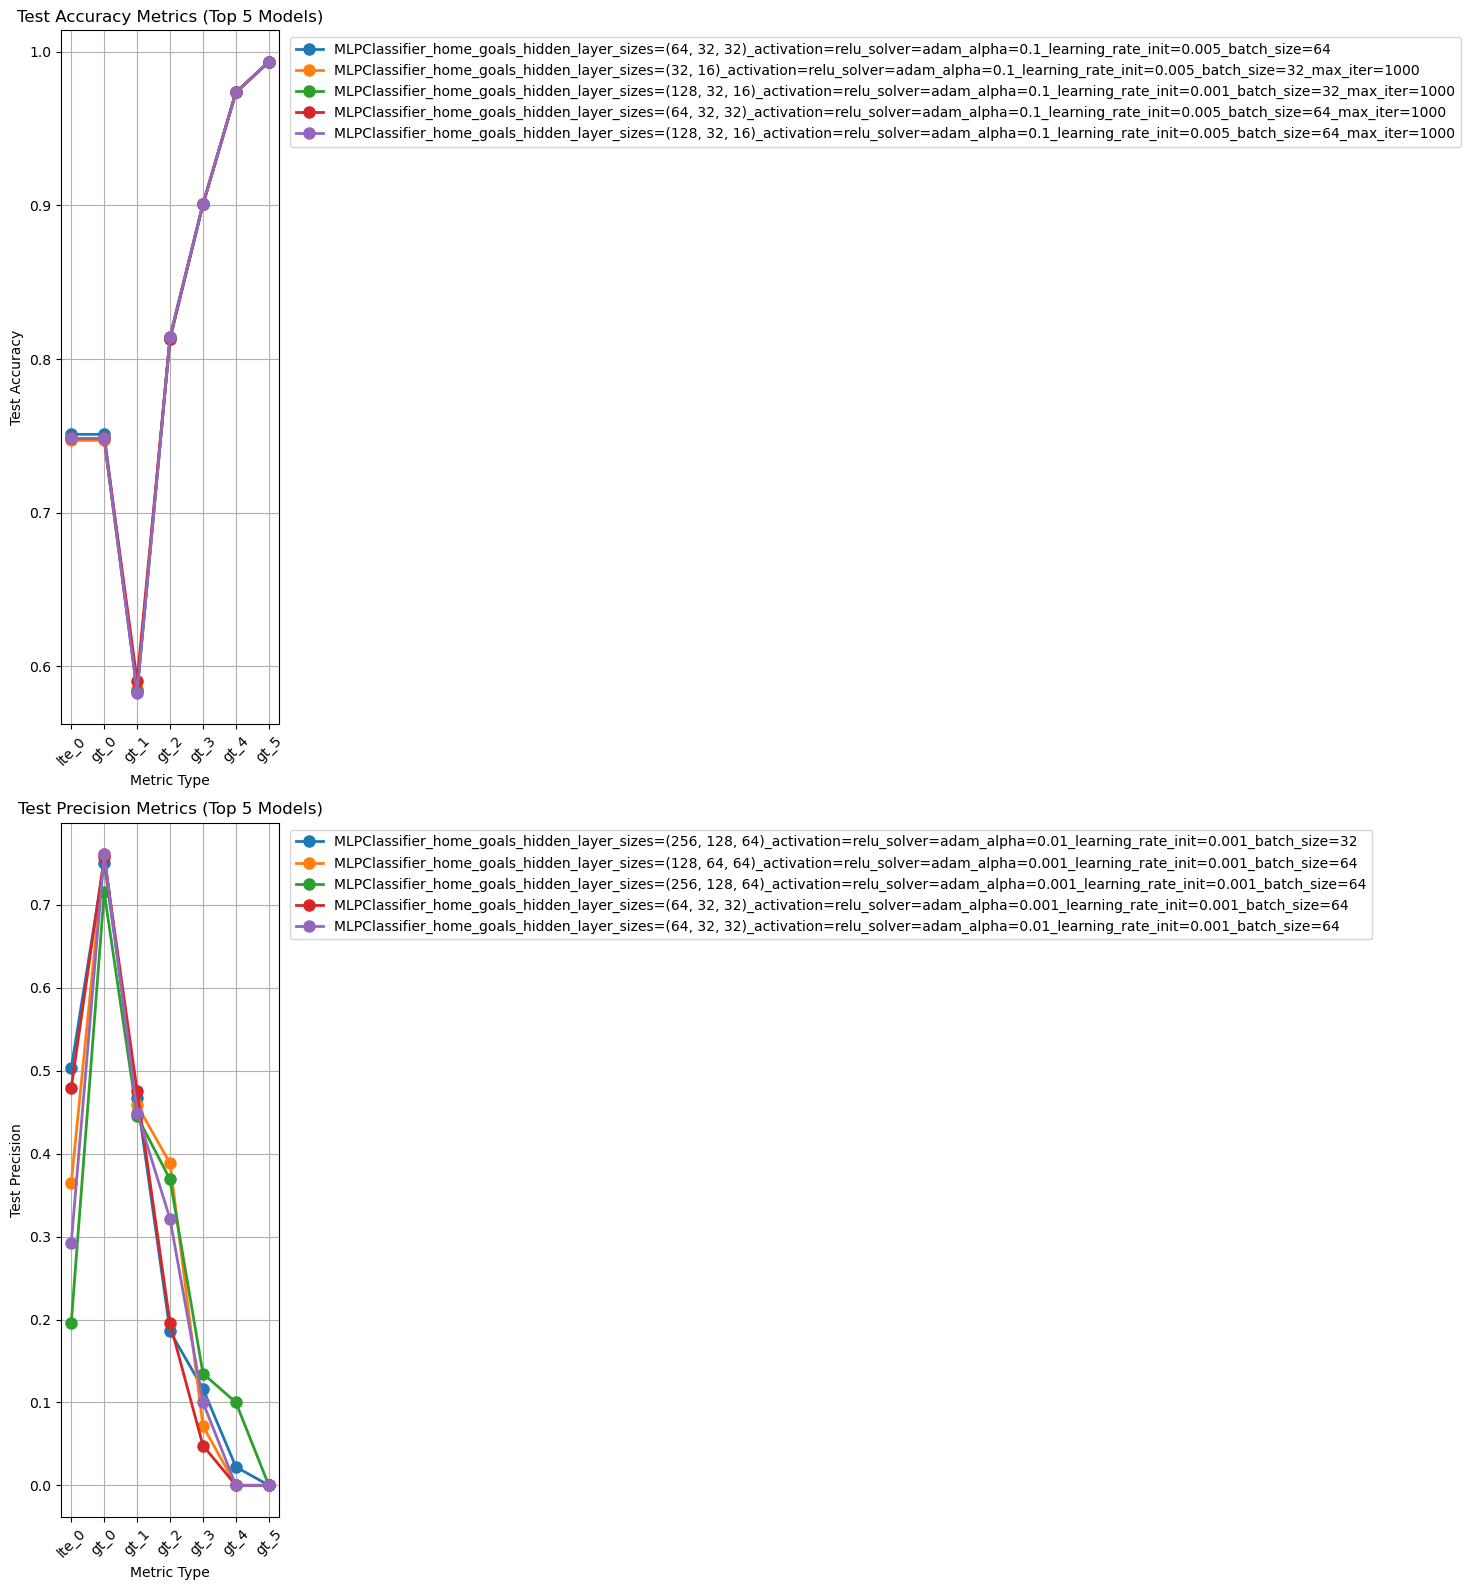

In [10]:
plot_metrics_for_target_and_model(
    experiment_name=EXPERIMENT_NAME,
    target_col="home_goals",
    model_name="MLPClassifier",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

In [11]:
def plot_run_metrics_by_split(experiment_name, run_name, target_col, tracking_uri):
    """
    Plot train, valid, and test metrics for a given run in an MLflow experiment.
    Metrics are already averaged across folds.
    """
    mlflow.set_tracking_uri(tracking_uri)
    experiment = mlflow.get_experiment_by_name(experiment_name)
    if experiment is None:
        print(f"Experiment '{experiment_name}' not found.")
        return

    # Find the run by name
    runs = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=f"tags.mlflow.runName = '{run_name}'",
        output_format="pandas"
    )
    if runs.empty:
        print(f"No run found with name '{run_name}'.")
        return

    run = runs.iloc[0]
    
    # Create figure with subplots vertically arranged
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 16))
    
    for ax, metric_type in [(ax1, "accuracy"), (ax2, "precision")]:
        splits = ["train", "valid", "test"]
        x_labels = None
        
        for split in splits:
            metrics = {}
            # Collect all metrics for this split and metric type (excluding std)
            split_metrics = {
                k: v for k, v in run.items() 
                if (f"{target_col}_{split}_" in k) and 
                k.endswith(f"_{metric_type}") and 
                not k.endswith("_std")
            }
            
            if not x_labels:
                # Create x_labels based on metric types in a specific order
                lte_metrics = sorted(
                    [(k, v) for k, v in split_metrics.items() if "_lte_" in k],
                    key=lambda x: int(x[0].split("_")[-2])
                )
                gt_metrics = sorted(
                    [(k, v) for k, v in split_metrics.items() if "_gt_" in k],
                    key=lambda x: int(x[0].split("_")[-2])
                )
                
                x_labels = (
                    [f"lte_{k.split('_')[-2]}" for k, _ in lte_metrics] +
                    [f"gt_{k.split('_')[-2]}" for k, _ in gt_metrics]
                )
                print(lte_metrics, gt_metrics)
                print(x_labels)
            
            values = []
            for label in x_labels:
                if label.startswith("lte_"):
                    threshold = label.split("_")[1]
                    key = f"metrics.{target_col}_{split}_lte_{threshold}_{metric_type}"
                else:  # gt
                    threshold = label.split("_")[1]
                    key = f"metrics.{target_col}_{split}_gt_{threshold}_{metric_type}"
                values.append(run[key])
            
            ax.plot(x_labels, values, marker='o', label=split,
                   markersize=8, linewidth=2)
        
        ax.set_title(f'{metric_type.capitalize()} Metrics Across Splits')
        ax.set_xlabel('Metric Type')
        ax.set_ylabel(f'{metric_type.capitalize()}')
        ax.grid(True)
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.setp(ax.get_xticklabels(), rotation=45)

    plt.tight_layout()
    plt.show()

[('metrics.home_goals_train_lte_0_accuracy', 0.7993388107548874)] [('metrics.home_goals_train_gt_0_accuracy', 0.7993388107548874), ('metrics.home_goals_train_gt_1_accuracy', 0.6895670262840813), ('metrics.home_goals_train_gt_2_accuracy', 0.8234654850900863), ('metrics.home_goals_train_gt_3_accuracy', 0.9236121151889332), ('metrics.home_goals_train_gt_4_accuracy', 0.9721767535031158), ('metrics.home_goals_train_gt_5_accuracy', 0.9873478041393027)]
['lte_0', 'gt_0', 'gt_1', 'gt_2', 'gt_3', 'gt_4', 'gt_5']
[('metrics.home_goals_train_lte_0_precision', 0.647498372929385)] [('metrics.home_goals_train_gt_0_precision', 0.8595974975905211), ('metrics.home_goals_train_gt_1_precision', 0.7146367465612696), ('metrics.home_goals_train_gt_2_precision', 0.6306776555614588), ('metrics.home_goals_train_gt_3_precision', 0.5823541321747567), ('metrics.home_goals_train_gt_4_precision', 0.5996223316912972), ('metrics.home_goals_train_gt_5_precision', 0.7139740259740259)]
['lte_0', 'gt_0', 'gt_1', 'gt_2', 

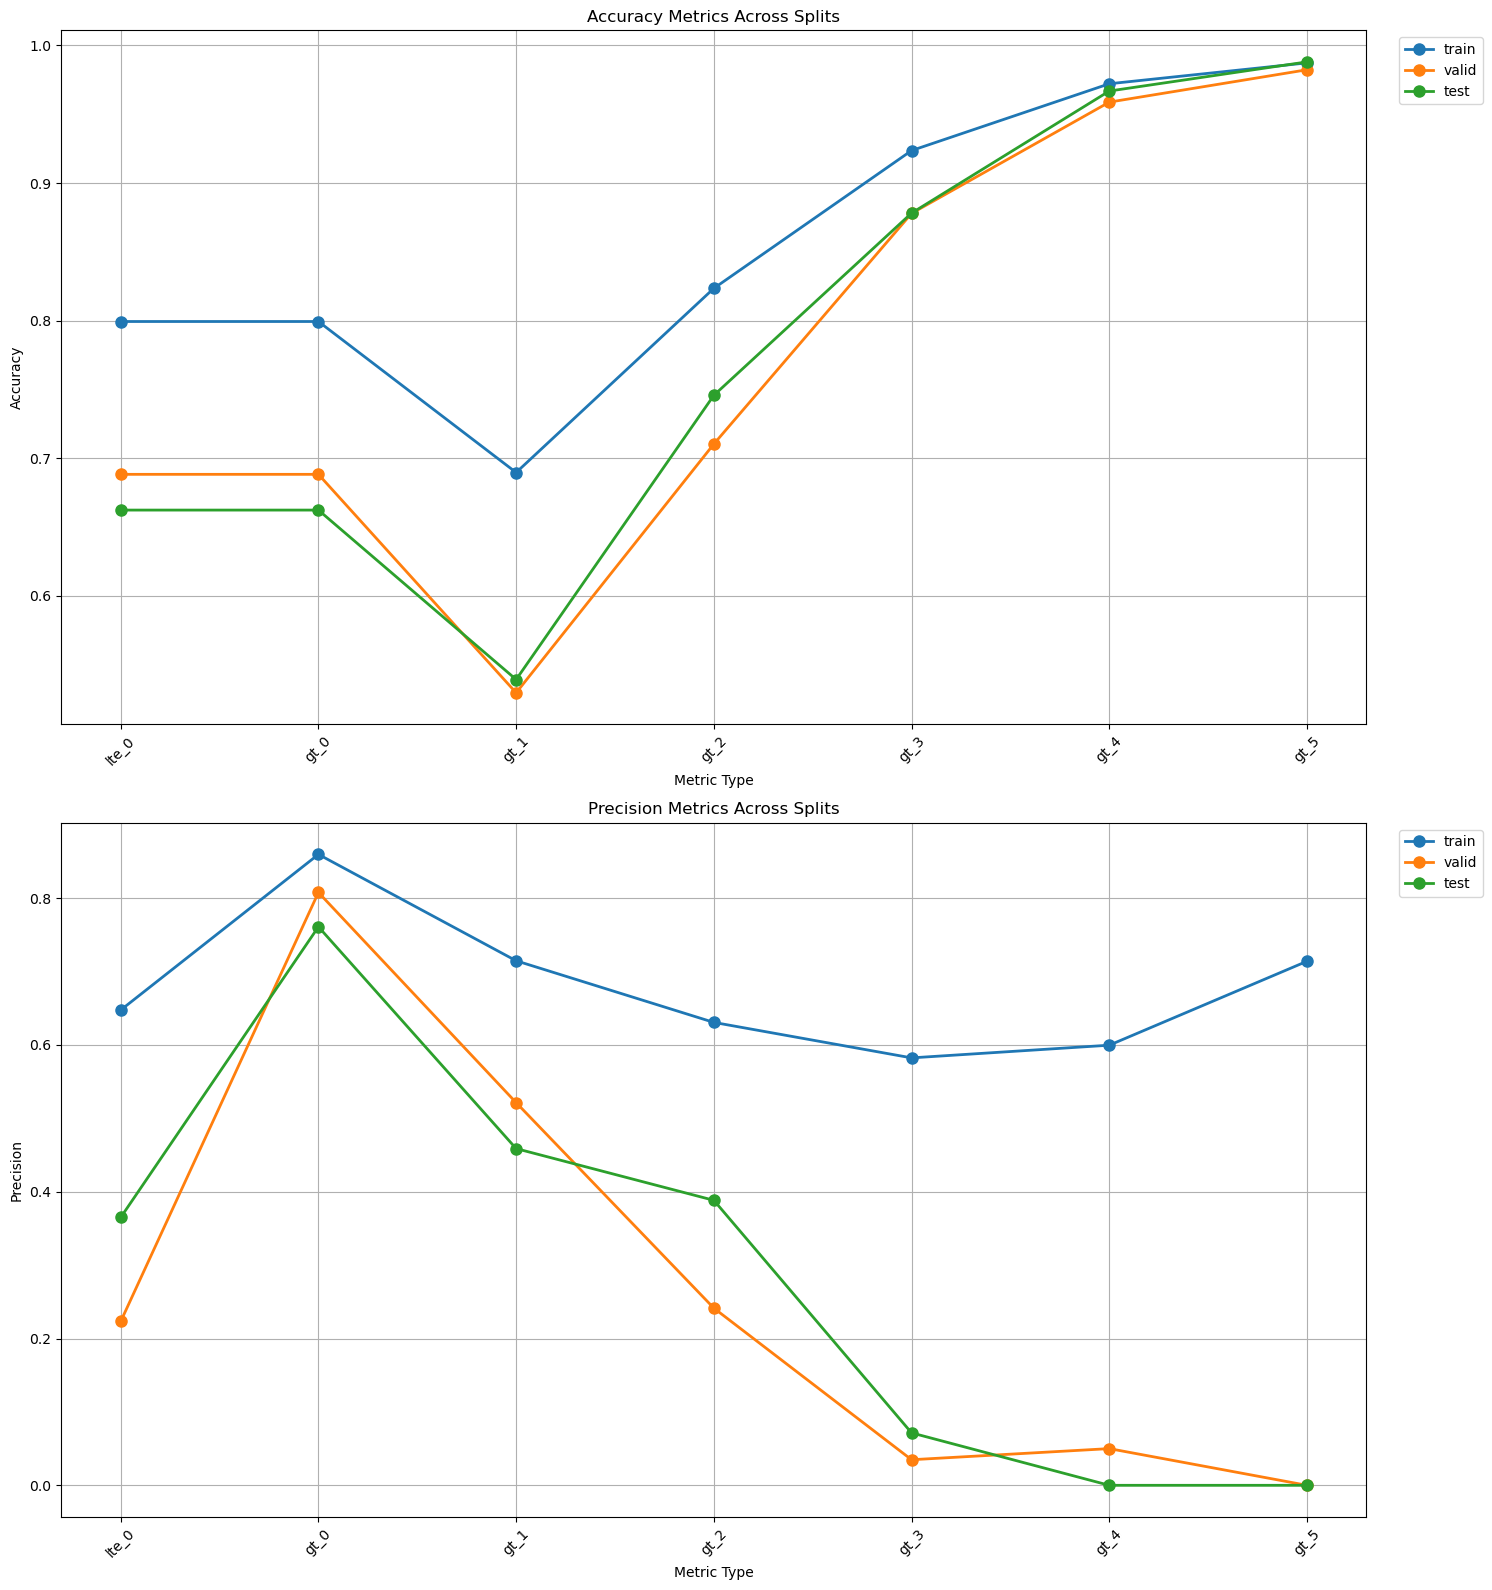

In [12]:
plot_run_metrics_by_split(experiment_name=EXPERIMENT_NAME,
                         run_name="MLPClassifier_home_goals_hidden_layer_sizes=(128, 64, 64)_activation=relu_solver=adam_alpha=0.001_learning_rate_init=0.001_batch_size=64",
                         target_col="home_goals",
                         tracking_uri=f"{REPO_PATH}/mlflow")